<a href="https://colab.research.google.com/github/IndiraTejaswini/Pytorch_Neural_networks/blob/main/Hugging_face_transformers_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The most basic object in the 🤗 Transformers library is the pipeline() function. It connects a model with its necessary preprocessing and postprocessing steps, allowing us to directly input any text and get an intelligible answer:

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
classifier("I've been waiting for a HuggingFace course my whole life.")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9598049521446228}]

In [ ]:
classifier(
    ["I've been waiting for a HuggingFace course my whole life.", "I hate this so much!"]
)

[{'label': 'POSITIVE', 'score': 0.9598049521446228},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

By default, this pipeline selects a particular pretrained model that has been fine-tuned for sentiment analysis in English. The model is downloaded and cached when you create the classifier object. If you rerun the command, the cached model will be used instead and there is no need to download the model again.


There are three main steps involved when you pass some text to a pipeline:

The text is preprocessed into a format the model can understand.

The preprocessed inputs are passed to the model.

The predictions of the model are post-processed, so you can make sense of them.

The pipeline() function supports multiple modalities, allowing you to work with text, images, audio, and even multimodal tasks.

In [ ]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification")
classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "politics", "business"],
)

[transformers] No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

{'sequence': 'This is a course about the Transformers library',
 'labels': ['education', 'business', 'politics'],
 'scores': [0.8445992469787598, 0.11197403818368912, 0.0434267520904541]}

This pipeline is called zero-shot because you don’t need to fine-tune the model on your data to use it. It can directly return probability scores for any list of labels you want!


zero-shot-classification: Classify text without prior training on specific labels

In [ ]:
from transformers import pipeline

generator = pipeline("text-generation")
generator("In this course, we will teach you how to")

[transformers] No model was supplied, defaulted to HuggingFaceTB/SmolLM3-3B and revision a07cc9a.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/26.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/5.60k [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[{'generated_text': 'In this course, we will teach you how to use the Python programming language to create a simple calculator program. This program will allow users to input their calculations and perform them. \n\nWe will start by discussing the basics of Python, including variables, data types, and control structures. We will then move on to more advanced topics, such as functions, loops, and conditional statements.\n\nThroughout the course, we will provide you with step-by-step instructions and examples to help you understand the code. We will also provide you with a final project that you can use to practice your new skills.\n\nHere is a basic outline of what we will cover:\n\n*   Introduction to Python and its basics\n*   Variables, data types, and control structures\n*   Functions, loops, and conditional statements\n*   Creating a simple calculator program\n*   Testing and debugging your code\n*   Best practices and coding standards\n\nThis course is ideal for beginners who hav

You can control how many different sequences are generated with the argument num_return_sequences and the total length of the output text with the argument max_length.

In [ ]:
from transformers import pipeline

generator = pipeline("text-generation", model="HuggingFaceTB/SmolLM2-360M")
generator(
    "In this course, we will teach you how to",
    max_length=30,
    num_return_sequences=2,
)

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.66k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will

[{'generated_text': 'In this course, we will teach you how to use the Python programming language to solve real-world problems. We will start by introducing you to the basics of Python, such as variables, functions, and data types. We will then build up to more complex concepts, such as functions with parameters and return values. Finally, we will look at some real-world examples of how Python can be used in a variety of fields, including finance, healthcare, and science.\n\nThroughout the course, we will use a variety of examples to help illustrate the concepts we are teaching. For example, we might use a Python program to simulate the stock market, or we might use a Python program to analyze medical data. We will also make sure to include plenty of examples of code written in Python, so that you can see how it is used in practice.\n\nIn this course, we will emphasize the importance of programming practice and the need for the Python programming language to be used in its correct cont

The previous examples used the default model for the task at hand, but you can also choose a particular model from the Hub to use in a pipeline for a specific task — say, text generation.

**Inference Providers**

All the models can be tested directly through your browser using the Inference Providers, which is available on the Hugging Face website. You can play with the model directly on this page by inputting custom text and watching the model process the input data.

Inference Providers that powers the widget is also available as a paid product, which comes in handy if you need it for your workflows.

In [ ]:
from transformers import pipeline

unmasker = pipeline("fill-mask")
unmasker("This course will teach you all about <mask> models.", top_k=2)

[transformers] No model was supplied, defaulted to distilbert/distilroberta-base and revision fb53ab8.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

[transformers] RobertaForMaskedLM LOAD REPORT from: distilbert/distilroberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[{'score': 0.196197509765625,
  'token': 30412,
  'token_str': ' mathematical',
  'sequence': 'This course will teach you all about mathematical models.'},
 {'score': 0.04052724316716194,
  'token': 38163,
  'token_str': ' computational',
  'sequence': 'This course will teach you all about computational models.'}]

The top_k argument controls how many possibilities you want to be displayed. Note that here the model fills in the special <mask> word, which is often referred to as a mask token. Other mask-filling models might have different mask tokens, so it’s always good to verify the proper mask word when exploring other models. One way to check it is by looking at the mask word used in the widget.

**Named entity recognition (NER)** is a task where the model has to find which parts of the input text correspond to entities such as persons, locations, or organizations.

In [ ]:
!pip install -U transformers[torch]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 75.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.2
    Uninstalling transformers-5.10.2:
      Successfully uninstalled transformers-5.10.2


In [ ]:
from transformers import pipeline

# 'aggregation_strategy' replaces 'grouped_entities'
ner = pipeline("ner", aggregation_strategy="simple")

results = ner("My name is Sylvain and I work at Hugging Face in Brooklyn.")
print(results)

[transformers] No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'entity_group': 'PER', 'score': np.float32(0.9981694), 'word': 'Sylvain', 'start': 11, 'end': 18}, {'entity_group': 'ORG', 'score': np.float32(0.9796019), 'word': 'Hugging Face', 'start': 33, 'end': 45}, {'entity_group': 'LOC', 'score': np.float32(0.9932106), 'word': 'Brooklyn', 'start': 49, 'end': 57}]


odern NLP models (like BERT) break words down into smaller chunks called "sub-tokens" to handle a massive vocabulary efficiently. For example, the name "Sylvain" might be split into ['S', '##yl', '##va', '##in'], and "Hugging Face" becomes ['Hugging', 'Face'].


Without an aggregation strategy, the model would output a separate prediction for every single sub-token. aggregation_strategy tells the pipeline how to merge those sub-token predictions back into the original, full words or phrases.



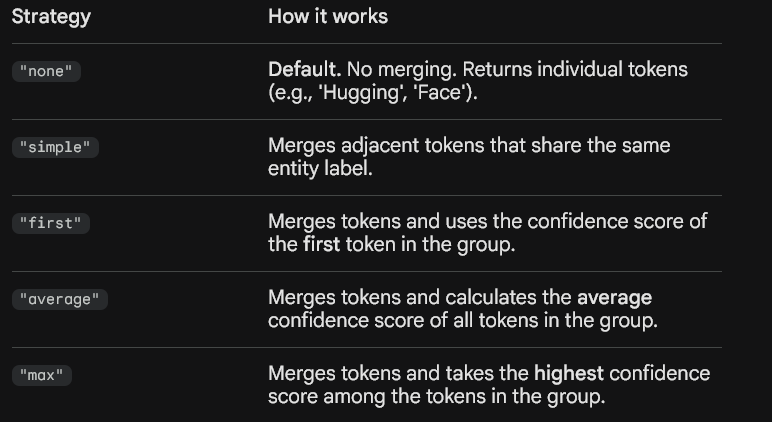

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("t5-small")
model = AutoModelForSeq2SeqLM.from_pretrained("t5-small")

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
text_to_summarize = """
    America has changed dramatically during recent years. Not only has the number of
    graduates in traditional engineering disciplines such as mechanical, civil,
    electrical, chemical, and aeronautical engineering declined, but in most of
    the premier American universities engineering curricula now concentrate on
    and encourage largely the study of engineering science. As a result, there
    are declining offerings in engineering subjects dealing with infrastructure,
    the environment, and related issues, and greater concentration on high
    technology subjects, largely supporting increasingly complex scientific
    developments. While the latter is important, it should not be at the expense
    of more traditional engineering.

    Rapidly developing economies such as China and India, as well as other
    industrial countries in Europe and Asia, continue to encourage and advance
    the teaching of engineering. Both China and India, respectively, graduate
    six and eight times as many traditional engineers as does the United States.
    Other industrial countries at minimum maintain their output, while America
    suffers an increasingly serious decline in the number of engineering graduates
    and a lack of well-educated engineers.
"""

inputs = tokenizer(text_to_summarize, max_length=1024, truncation=True, return_tensors="pt")
summary_ids = model.generate(inputs.input_ids, num_beams=4, max_length=100, early_stopping=True)
summary_text = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Format the output as requested
formatted_output = [{'summary_text': summary_text}]
print(formatted_output)

[{'summary_text': 'has changed dramatically in recent years. In most of the premier American universities engineering curricula now concentrate on and encourage the study of engineering science. As a result, there are declining offerings in engineering subjects dealing with infrastructure, the environment, and related issues, and greater concentration on high technology subjects.'}]


tokenizer.decode(translated_ids[0], skip_special_tokens=True)
translated_ids[0]: The model usually returns a "batch" of results. Since you provided a single sentence, you access the first (and only) result using [0].

skip_special_tokens=True: Models often use special tokens (like <s>, </s>, or <pad>) to mark the beginning, end, or padding of a sentence. This argument tells the tokenizer to strip those out so you get a clean, human-readable sentence.

The Result (translated_text): This converts those numbers back into the actual language output (e.g., "This course is produced by Hugging Face").

"pt" stands for PyTorch.

By adding this argument, the tokenizer returns the input data as PyTorch tensors instead of the default Python lists.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# The 'translation' task is currently not recognized by the pipeline function.
# We will directly load the model and tokenizer to perform translation.

model_name = "Helsinki-NLP/opus-mt-fr-en"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

text_to_translate = "Ce cours est produit par Hugging Face."

# Prepare the text for translation
inputs = tokenizer(text_to_translate, return_tensors="pt")

# Generate the translation
# The generate method often takes arguments like max_length, num_beams, etc. for control over generation.
# For simple translation, default behavior might suffice or we can specify max_length.
translated_ids = model.generate(**inputs, max_length=40)

# Decode the translated text
translated_text = tokenizer.decode(translated_ids[0], skip_special_tokens=True)

print(f"Original (French): {text_to_translate}")
print(f"Translated (English): {translated_text}")

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Original (French): Ce cours est produit par Hugging Face.
Translated (English): This course is produced by Hugging Face.


In [ ]:
from transformers import pipeline

image_classifier = pipeline(
    task="image-classification", model="google/vit-base-patch16-224"
)
result = image_classifier(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
)
print(result)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

[{'label': 'lynx, catamount', 'score': 0.43339791893959045}, {'label': 'cougar, puma, catamount, mountain lion, painter, panther, Felis concolor', 'score': 0.03480524197220802}, {'label': 'snow leopard, ounce, Panthera uncia', 'score': 0.03240473195910454}, {'label': 'Egyptian cat', 'score': 0.023974036797881126}, {'label': 'tiger cat', 'score': 0.022902466356754303}]


In [ ]:
from transformers import pipeline

transcriber = pipeline(
    task="automatic-speech-recognition", model="openai/whisper-large-v3"
)
result = transcriber(
    "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/mlk.flac"
)
print(result)

config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.90k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.07k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see re

{'text': ' I have a dream that one day this nation will rise up and live out the true meaning of its creed.'}
